# ***FAKE NEWS DETECTION USING MACHINE LEARNING AND DEEP LEARNING MODELS***

## IMPORT LIBRARIES

In [1]:
#install pre-requisites
!pip install seaborn
!pip install catboost
!pip install textstat


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.1 MB/s eta 0:00:00


In [2]:
#libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re
import string
import nltk
import spacy
import time
import PIL.Image
import gensim
from gensim.models import Word2Vec
from collections import Counter
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textstat import flesch_reading_ease
from nltk.corpus import cmudict, stopwords, wordnet
from nltk import pos_tag
from sklearn import preprocessing
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import sent_tokenize, RegexpTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from textblob import TextBlob

In [3]:
#download
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('vader_lexicon')
nltk.download('cmudict')
nltk.download('stopwords')
nltk.download('words')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
#settings

# print complete array
np.set_printoptions(threshold=np.inf)

# display all rows
pd.set_option('display.max_rows', None)

# display all columns
pd.set_option('display.max_columns', None)

## LOAD THE DATASETS

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df_true = pd.read_csv('/content/drive/MyDrive/dissertation/dataset/True.csv')

In [7]:
df_fake = pd.read_csv('/content/drive/MyDrive/dissertation/dataset/Fake.csv')

## ANALYSING THE DATASET

### TRUE DATA

In [8]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [9]:
df_true.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [10]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
# duplicate count
df_true[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    591
text     225
dtype: int64

In [12]:
# Subject value count
df_true['subject'].value_counts()

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

<ipython-input-13-368877f8db1b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data=True_News, width=0.4, palette='deep')


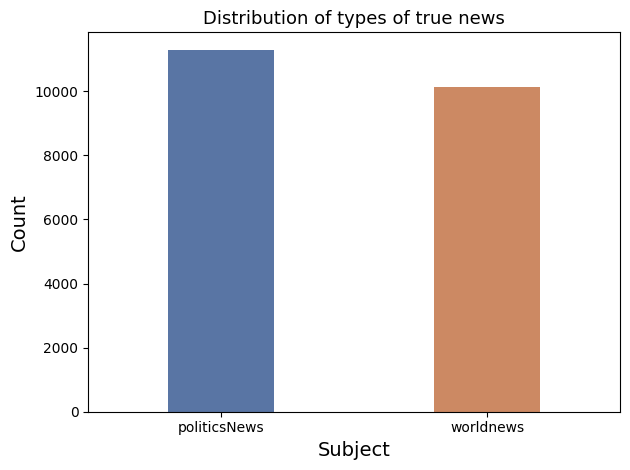

In [13]:
# visualising the subject column
True_News = df_true
sns.countplot(x='subject', data=True_News, width=0.4, palette='deep')
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of types of true news', fontsize=13)
plt.tight_layout()  # to ensure proper spacing
plt.savefig("True_subjects.jpeg")
plt.show()

In [14]:
# Date value count
df_true.date.value_counts()

date
December 20, 2017      182
December 6, 2017       166
November 30, 2017      162
November 9, 2017       158
October 13, 2017       155
September 21, 2017     153
December 21, 2017      151
September 6, 2017      151
September 7, 2017      149
September 22, 2017     146
October 19, 2017       145
November 8, 2017       143
September 12, 2017     143
October 18, 2017       142
October 26, 2017       142
September 15, 2017     141
October 16, 2017       141
December 7, 2017       140
October 24, 2017       139
October 12, 2017       137
September 26, 2017     136
October 25, 2017       136
November 29, 2017      134
December 8, 2017       134
December 14, 2017      133
September 14, 2017     131
December 5, 2017       131
November 21, 2017      129
November 2, 2017       128
November 1, 2017       127
September 28, 2017     126
December 13, 2017      126
November 28, 2017      125
October 11, 2017       125
December 19, 2017      124
November 24, 2017      124
November 17, 2017      

### FAKE DATA

In [15]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [16]:
df_fake.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [17]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [18]:
# duplicate count
df_fake[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    5578
text     6026
dtype: int64

In [19]:
# Count of subject categories
df_fake['subject'].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

<ipython-input-20-c7513c7dc960>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data = Fake_News, palette='deep')


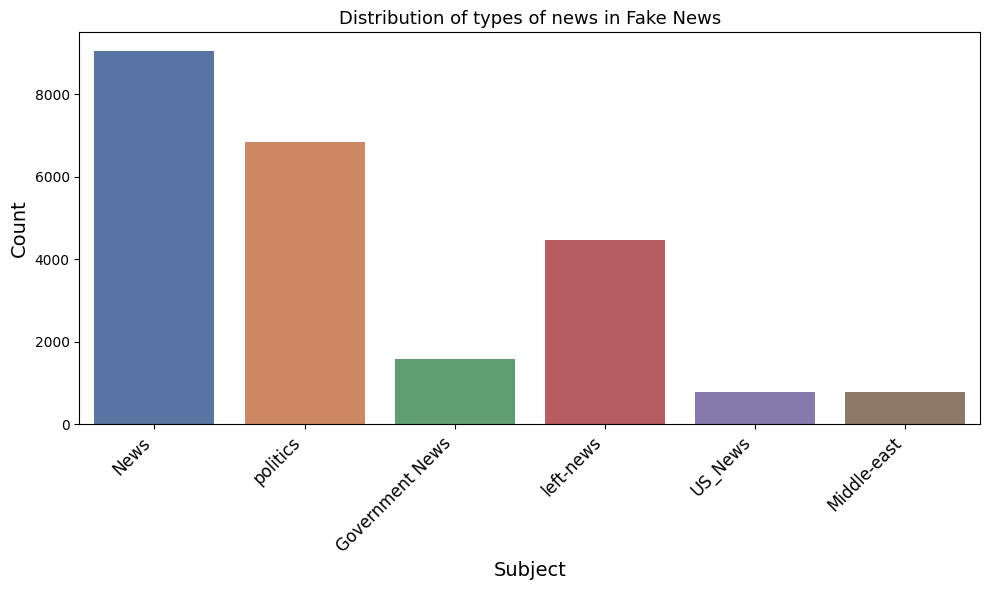

In [20]:
# Visualising the subject column
Fake_News = df_fake
plt.figure(figsize=(10, 6))
sns.countplot(x='subject', data = Fake_News, palette='deep')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of types of news in Fake News', fontsize=13)
plt.tight_layout()  # to ensure proper spacing
plt.savefig("Fake_subjects.jpeg")
plt.show()

In [21]:
# date value count
df_fake.date.value_counts()

date
May 10, 2017                                                                                                                                             46
May 26, 2016                                                                                                                                             44
May 6, 2016                                                                                                                                              44
May 5, 2016                                                                                                                                              44
May 11, 2016                                                                                                                                             43
May 12, 2016                                                                                                                                             42
May 12, 2017                                               

## DATA PREPROCESSING

### Labelling FAKE = 1 and TRUE = 0

In [22]:
# Labelling TRUE = 0
df_true["label"] = 0
df_true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [35]:
df_true.shape

(21417, 5)

In [23]:
# Labelling FAKE = 1
df_fake["label"] = 1
df_fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [36]:
df_fake.shape

(23481, 5)

### Joining the datasets



In [24]:
# Combining Fake and True dataframes
df_news = pd.concat([df_fake, df_true], axis=0)
df_news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [26]:
df_news.shape

(44898, 5)

### Shuffling the dataset

In [27]:
# Shuffling the dataset
df_news = df_news.sample(frac = 1, random_state = 2310246)
df_news.head()

,title,text,subject,date,label
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,News,"March 24, 2017",1
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0


### Removing duplicates

In [28]:
# number of duplicates present in title and text column
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    6169
text     6252
dtype: int64

In [29]:
# Removing duplicates in the text column
df_news= df_news.drop_duplicates(subset=['text'], keep='last')
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    376
text       0
dtype: int64

In [30]:
# duplicated value present in title column
title = df_news["title"]
df_news_dup = df_news[title.isin(title[title.duplicated()])].sort_values("title")
df_news_dup.head()

,title,text,subject,date,label
1535,McConnell Says He’ll Obstruct ANY Effort To H...,Siding with Trump s Attorney General Jeff Sess...,News,"May 10, 2017",1
1488,McConnell Says He’ll Obstruct ANY Effort To H...,Siding with Trump s Attorney General Jeff Sess...,News,"May 12, 2017",1
15031,'Can I get it to go?' Canada's Trudeau charms ...,MANILA (Reuters) - Canadian Prime Minister Jus...,worldnews,"November 12, 2017",0
674,'Can I get it to go?' Canada's Trudeau charms ...,MANILA (Reuters) - Canadian Prime Minister Jus...,politicsNews,"November 12, 2017",0
12126,'Fierce and formidable' Dlamini-Zuma eyes Sout...,JOHANNESBURG (Reuters) - Nkosazana Dlamini-Zum...,worldnews,"December 16, 2017",0


In [31]:
# sample duplicate text
df_news_dup.text.iloc[0]

'Siding with Trump s Attorney General Jeff Sessions and Trump s spokesperson, McConnell told America from the floor of the Senate that he sees no reason to assign an independent special prosecutor or create a bipartisan committee to get to the bottom of Trump s relationship to Russia.JUST NOW: McConnell says new investigation will only impede current work on Russia investigations.(so no special prosecutor or committee)  John Berman (@JohnBerman) May 10, 2017McConnell was rebuffing Senate Minority Leader Chuck Schumer s renewed call for an independent investigator. I have said from the get-go that I think a special prosecutor is the way to go, but now with what s happened it is the only way to go,  Schumer told reporters on Tuesday.Instead, McConnell said he would leave that up to the FBI   and let Jeff Sessions handpick Comey s  interim  (read: non-confirmed) FBI head, something that is not standard procedure.News: AG Sessions & Deputy AG Rosenstein interviewing potential interim FBI d

In [32]:
# sample duplicate text
df_news_dup.text.iloc[1]

'Siding with Trump s Attorney General Jeff Sessions and Trump s spokesperson, McConnell told America from the floor of the Senate that he sees no reason to assign an independent special prosecutor or create a bipartisan committee to get to the bottom of Trump s relationship to Russia.JUST NOW: McConnell says new investigation will only impede current work on Russia investigations.(so no special prosecutor or committee)  John Berman (@JohnBerman) May 10, 2017McConnell was rebuffing Senate Minority Leader Chuck Schumer s renewed call for an independent investigator. I have said from the get-go that I think a special prosecutor is the way to go, but now with what s happened it is the only way to go,  Schumer told reporters on Tuesday.Instead, McConnell said he would leave that up to the FBI   and let Jeff Sessions handpick Comey s  interim  (read: non-confirmed) FBI head, something that is not standard procedure.News: AG Sessions & Deputy AG Rosenstein interviewing potential interim FBI d

In [33]:
#removing the duplicates in the title column
df_news= df_news.drop_duplicates(subset=['title'], keep='last')
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    0
text     0
dtype: int64

In [34]:
df_news.shape

(38270, 5)

### Date formatting

In [ ]:
# remove sentences and hyperlinks

# Define a pattern to search for month abbreviations
pattern = "Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec"

# Loop over each index in the range of the length of the 'date' column
for index in range(0,len(df_news.date)):

    # Search for the pattern in the string representation of the date at the current index
    match_date = re.search(pattern, str(df_news.date.iloc[index]))

    # Check if a match is found
    if match_date != None:
        # If a match is found, keep the original date value
        df_news.date.iloc[index] = df_news.date.iloc[index]
    else:
        # If no match is found, set the date value to "WRONG"
        df_news.date.iloc[index] = "WRONG"

# Display the count of unique values in the 'date' column
df_news.date.value_counts()

Streaming output truncated to the last 5000 lines.
<ipython-input-32-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.date.iloc[index]
<ipython-input-32-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.date.iloc[index]
<ipython-input-32-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.dat

date
December 6, 2017       165
November 30, 2017      151
September 6, 2017      150
September 7, 2017      147
September 21, 2017     141
October 19, 2017       141
November 9, 2017       139
September 15, 2017     139
December 7, 2017       139
October 16, 2017       138
September 12, 2017     138
October 18, 2017       137
October 26, 2017       136
October 24, 2017       134
October 12, 2017       134
September 26, 2017     132
October 25, 2017       131
September 22, 2017     131
November 29, 2017      130
November 8, 2017       130
December 8, 2017       130
December 14, 2017      130
October 13, 2017       129
September 14, 2017     128
December 5, 2017       126
November 28, 2017      125
November 1, 2017       125
December 13, 2017      124
November 24, 2017      123
November 17, 2017      123
September 28, 2017     123
September 13, 2017     123
November 21, 2017      122
November 15, 2017      122
December 19, 2017      122
September 5, 2017      122
November 2, 2017       

In [ ]:
# Filter the DataFrame to exclude rows where the date is "WRONG"
df_news = df_news[df_news.date != "WRONG"]

df_news.shape

(38264, 5)

In [ ]:
# Formatting the date to a specific format

# Loop over each index in the range of the length of the 'date' column
for i in range (0, len(df_news.date)):

    # Get the date value at the current index
    input = df_news.date.iloc[i]

    # Convert the date string to a datetime object
    convert_date = pd.to_datetime(input)

    # Format the datetime object to a string in the format "Month day, Year"
    df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")

# Display the updated 'date' column of the DataFrame
df_news.date

Streaming output truncated to the last 5000 lines.
<ipython-input-34-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")
<ipython-input-34-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")
<ipython-input-34-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = 

2028         March 24, 2017
3683           May 19, 2017
2628          July 21, 2017
7808       October 15, 2016
1802     September 11, 2017
15152    September 28, 2015
12054     December 17, 2017
14649     November 16, 2017
15956     November 01, 2017
15499         July 07, 2015
15089     November 11, 2017
5788      February 01, 2017
3330      December 20, 2016
16090      October 30, 2017
19125    September 25, 2017
18223      October 05, 2017
17786      October 10, 2017
9099      December 29, 2017
5811      February 01, 2017
7039         April 07, 2016
6748         April 23, 2016
1124       October 20, 2017
14712      January 03, 2016
13328     December 01, 2017
19374    September 22, 2017
15375     November 08, 2017
8830       January 11, 2016
891       November 02, 2017
10670         June 08, 2017
14844     November 14, 2017
7091      November 23, 2016
3523      December 07, 2016
20691    September 07, 2017
12025     December 18, 2017
1757     September 21, 2017
6778      December 1

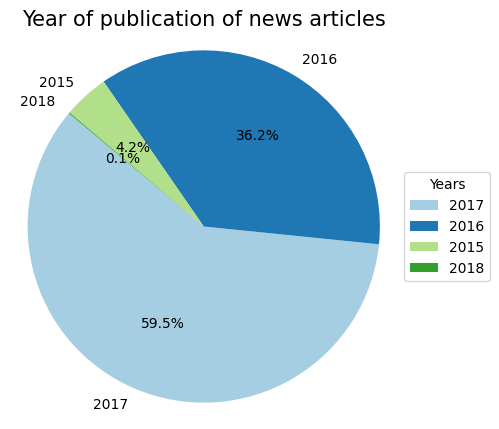

In [ ]:
# Visualising the date column with respect to year

# Extract the year from the datetime objects and count occurrences of each year
year_count = pd.to_datetime(df_news['date']).dt.year.value_counts()

plt.figure(figsize=(5,5))
colors = plt.cm.Paired.colors
plt.pie(year_count, labels=year_count.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 10})
plt.legend(year_count.index, title='Years', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.axis('equal')
plt.title('Year of publication of news articles', fontsize=15)
plt.savefig("news_dates.jpeg", dpi=300, bbox_inches='tight')
plt.show()

### Renaming subject column values

In [ ]:
# Subject value count
df_news.subject.value_counts()

subject
politicsNews       11001
worldnews           9819
News                9049
politics            4325
left-news           2394
Government News      893
Middle-east          415
US_News              368
Name: count, dtype: int64

In [ ]:
# Renaming the subject category
df_news.subject.replace({"News" : "worldnews", "politics": "politicsNews" }, inplace = True)

In [ ]:
# Subject value count after renaming
df_news.subject.value_counts()

subject
worldnews          18868
politicsNews       15326
left-news           2394
Government News      893
Middle-east          415
US_News              368
Name: count, dtype: int64

### Feature encoding

In [ ]:
# Create dummy variables for the 'subject' column
dummies = pd.get_dummies(df_news['subject'], prefix="subject", drop_first=True)

# Concatenate the dummy variables to the original DataFrame
df_news = pd.concat([df_news, dummies], axis=1)

In [ ]:
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False


## TEXT PREPROCESSING

### Changing to lower case

In [ ]:
# Converting text to lower case
df_news['text_lowercase'] = df_news["text"].str.lower()
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside..."
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...


### Punctuation removal

In [ ]:
def punctuation_removal (text):
    text = re.sub('https?://\S+|www\.\S+', '', text) # Remove URLs starting with http, https, or www
    text = re.sub('<.*?>+', '', text) # Remove HTML tags
    text = re.sub('\[.*?\]', '', text) # Remove text within square brackets
    text = re.sub("\\W"," ",text) # Replace non-word characters (everything except numbers and letters) with a space
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub('\n', '', text) # Remove newline characters
    text = re.sub('\w*\d\w*', '', text) # Remove words containing numbers
    return text

In [ ]:
df_news['text_punc'] = df_news['text_lowercase'].apply(lambda x: punctuation_removal(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...


### Stopwords removal

In [ ]:
# List of stopwords
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [ ]:
# delete duplicates using set function
StopWords = set(stopwords.words('english'))
def discard_stopwords(text):
    return " ".join([word for word in text.split() if word not in StopWords])

In [ ]:
df_news['text_stopwords'] = df_news['text_punc'].apply( lambda x: discard_stopwords(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...


### Frequent words removal

In [ ]:
# Initialize a Counter object to store word counts
WordCount = Counter()
# Loop through each text entry in the 'text_stopwords' column of the DataFrame
for text in df_news['text_stopwords']:
     # Split the text into individual words and count each word
     for word in text.split():
        WordCount[word] += 1

# Get the 200 most common words and their counts
WordCount.most_common(200)

[('said', 120763),
 ('trump', 120286),
 ('would', 48859),
 ('u', 48497),
 ('president', 47779),
 ('people', 36007),
 ('one', 31877),
 ('state', 29830),
 ('reuters', 28424),
 ('also', 26801),
 ('new', 26785),
 ('donald', 25366),
 ('government', 24487),
 ('house', 24466),
 ('republican', 23538),
 ('states', 23384),
 ('clinton', 22846),
 ('obama', 22488),
 ('year', 21726),
 ('could', 21020),
 ('united', 20608),
 ('told', 20367),
 ('white', 19479),
 ('campaign', 19101),
 ('like', 18898),
 ('two', 18849),
 ('election', 18729),
 ('party', 18486),
 ('last', 18407),
 ('time', 17918),
 ('washington', 16316),
 ('first', 16224),
 ('news', 15992),
 ('country', 15683),
 ('even', 15138),
 ('former', 15117),
 ('years', 14176),
 ('many', 13961),
 ('security', 13591),
 ('law', 13427),
 ('say', 13361),
 ('republicans', 13354),
 ('percent', 13305),
 ('may', 13260),
 ('court', 13173),
 ('made', 13069),
 ('national', 12979),
 ('since', 12874),
 ('american', 12856),
 ('right', 12727),
 ('political', 12696),

In [ ]:
# Removing manually selected list of frequently occurring words
frequently_occuring_words = ("said","U","would","one","also","new","house","like","two","last","time","first","even","many","say","may","made","since","get","make","us","way","know","think","take","well","day","see","says","go","three","com","old","end","top")

def discard_frequent_words(text):
    return " ".join([word for word in text. split() if word not in frequently_occuring_words])

In [ ]:
df_news['text_frequent'] = df_news['text_stopwords'].apply( lambda x: discard_frequent_words(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...


### Rare words removal

In [ ]:
# Create a set of words that are considered rare based on their word count
rare_words = set(word for (word, wc) in WordCount.most_common() if wc <= 150)
rare_words

{'drags',
 'dishonorably',
 'tonybriscoe',
 'underoos',
 'brexiting',
 'daylinleach',
 'rebeccashabad',
 'anaconda',
 'bogeys',
 'ply',
 'ndrangheta',
 'annuity',
 'maastricht',
 'takajarvi',
 'statesman',
 'garr',
 'shahidul',
 'ericteetsel',
 'mamasapano',
 'cruzin',
 'trunk',
 'muehlhausen',
 'paddington',
 'branco',
 'oppresso',
 'podemos',
 'shrive',
 'lifts',
 'harnish',
 'byronyork',
 'refills',
 'aliarau',
 'christoph',
 'newsdisney',
 'debbuddsw',
 'molins',
 'gptwo',
 'mosychuk',
 'backwoods',
 'scratching',
 'parentelement',
 'thekitastrophe',
 'glatt',
 'aweil',
 'corallo',
 'dirhams',
 'mindlessness',
 'fleeced',
 'hadramaut',
 'corbitt',
 'magnanimous',
 'ionut',
 'juarez',
 'underequipped',
 'brucearthur',
 'freelancers',
 'adeline',
 'beckoning',
 'virtu',
 'accessed',
 'zelikow',
 'bunkosquad',
 'emptive',
 'heavyweights',
 'riskier',
 'bram',
 'myhlee',
 'pasadena',
 'sol',
 'nbcnewspr',
 'journalpresident',
 'oblique',
 'localities',
 'akkad',
 'kars',
 'offs',
 'sca

In [ ]:
# function to discard rare words
def discard_rare(text):
    return " ".join([word for word in text.split() if word not in rare_words])

In [ ]:
df_news['text_rare'] = df_news['text_frequent'].apply( lambda x: discard_rare(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent,text_rare
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...,federal court struck version muslim ban basica...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james n...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...,washington reuters co founder firm dossier don...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...


### Word cloud

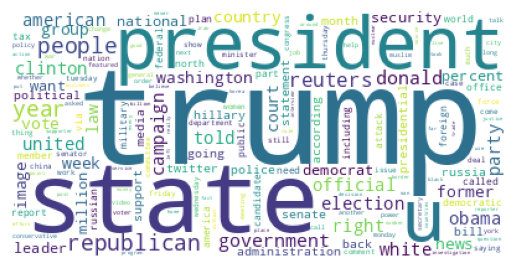

In [ ]:
# word cloud for the combined dataset
Text_WordCloud = " ".join(word for word in df_news.text_rare)

word_cloud = WordCloud(random_state = 2310246,
                       background_color="white",
                       collocations=False,
                       stopwords=STOPWORDS,
                       ).generate(Text_WordCloud)

plt.imshow(word_cloud)
plt.axis("off")
plt.savefig("wordcloud_news.jpeg", dpi=300, bbox_inches='tight')
plt.show()

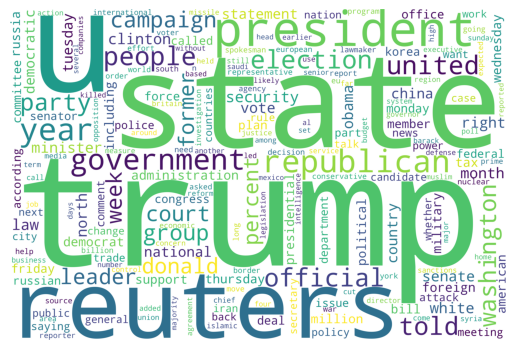

In [ ]:
# word cloud for true data
True_text_WordCloud = " ".join(word for word in df_news[df_news.label == 0].text_rare)

word_cloud_truedata = WordCloud(width = 6000,
                       height = 4000,
                       random_state = 2310246,
                       background_color="white",
                       collocations=False,
                       stopwords=STOPWORDS,
                       ).generate(True_text_WordCloud)

plt.imshow(word_cloud_truedata)
plt.axis("off")
plt.savefig("wordcloud_true.jpeg", dpi=300, bbox_inches='tight')
plt.show()

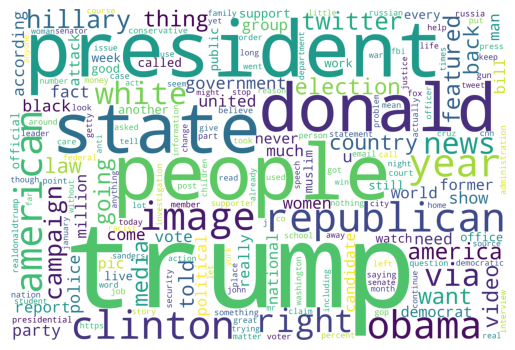

In [ ]:
# word cloud for fake data
Fake_text_WordCloud = " ".join(word for word in df_news[df_news.label == 1].text_rare)

word_cloud_fakedata = WordCloud(width = 6000,
                       height = 4000,
                       random_state = 2310246,
                       background_color="white",
                       collocations=False,
                       stopwords=STOPWORDS,
                       ).generate(Fake_text_WordCloud)

plt.imshow(word_cloud_fakedata)
plt.axis("off")
plt.savefig("wordcloud_fake.jpeg", dpi=300, bbox_inches='tight')
plt.show()

### Stemming

In [ ]:
# Initialize a PorterStemmer object
stemmer = PorterStemmer()

# Define a function to stem words in a given text
def stemming_text(text):
    words = text.split()
    stem_words = [stemmer.stem(word) for word in words]
    return " ".join(stem_words)

# Apply the stemming_text function to the 'text_rare' column
df_news['text_stemming'] = df_news['text_rare'].apply(stemming_text)
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent,text_rare,text_stemming
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...,federal court struck version muslim ban basica...,feder court struck version muslim ban basic do...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james n...,reuter goldman sach group inc banker jame nomi...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...,washington reuters co founder firm dossier don...,washington reuter co founder firm dossier dona...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlott n c reuter republican presidenti nomi...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuter republican lawmak devin nune investig w...


In [ ]:
# Initialize an empty set to store the unique words
vocabulary = set()

# Loop through each text entry in the 'text_stemmed' column of the DataFrame
for text in df_news['text_stemming']:
    words = text.split()
    vocabulary.update(words)

# Sort the vocabulary in alphabetical order
sort_vocab = sorted(vocabulary)

# Loop through the sorted vocabulary and print each word
for word in sort_vocab:
    print(word)

aaron
abadi
abandon
abba
abbott
abc
abdel
abdullah
abe
abedin
abid
abil
abl
aboard
abort
abroad
abruptli
absenc
absolut
absurd
abu
abus
aca
academ
academi
accept
access
accid
accident
accompani
accomplish
accord
account
accur
accuraci
accus
achiev
acknowledg
aclu
acosta
acr
across
act
action
activ
activist
actor
actress
actual
ad
adam
add
addict
addit
address
adequ
administr
admir
admiss
admit
adopt
adult
advanc
advantag
adversari
advertis
advic
advis
advisor
advisori
advoc
advocaci
afd
affair
affect
affili
afford
afghan
afghanistan
afraid
africa
african
aftermath
afternoon
afterward
ag
age
agenc
agenda
agent
aggress
ago
agre
agreement
agricultur
ahead
ahm
aid
ail
aim
air
aircraft
airlin
airport
aisl
al
alabama
alan
alarm
alaska
alcohol
aleppo
alert
alex
alexand
ali
alien
align
alik
aliv
alleg
allegedli
allegi
allen
alli
allianc
allow
almost
alon
along
alongsid
alphabet
alreadi
alt
altern
although
altogeth
alway
amaz
amazon
ambassador
ambit
ambiti
amend
america
american
ami
amid
ammon


In [ ]:
# create tokens
tokenizer = RegexpTokenizer(r'\w+')
df_news['tokens'] = df_news["text_rare"].apply(lambda text: tokenizer.tokenize(text))

## FEATURE EXTRACTION

In [ ]:
# Create a deep copy of the original dataframe df_news and assign it to df_news_features
df_news_features = df_news.copy(deep = True)

# Drop unnecessary columns from df_news_features
df_news_features = df_news.drop(['title','subject', 'date','text_lowercase','text_punc','text_stopwords','text_frequent','text_rare'], axis=1)

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,..."
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ..."
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi..."
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside..."
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ..."


## TEXTUAL FEATURES

### Uppercase count



In [ ]:
df_news_features['uc_count'] = df_news_features['text'].str.findall(r'[A-Z]').str.len()
df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107


### Lowercase count

In [ ]:
df_news_features['lc_count'] = df_news_features['text'].str.findall(r'[a-z]').str.len()
df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924


### Punctuation count

In [ ]:
# Define a regex pattern that matches any punctuation character
pattern = r'[{}]'.format(re.escape(string.punctuation))

# Function to count punctuation characters in a given text
def punc_count(text):
  tok = re.findall(r'\b\w+\b|' + pattern, text) # Tokenize the text into words and punctuation marks
  punc_tok = [token for token in tok if re.match(pattern, token)] # Filter out tokens that are punctuation marks
  return len(punc_tok)

# Apply the punctuation counting function to the 'text' column
df_news_features['punc_count'] = df_news_features['text'].apply(punc_count)

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74


### Character count

In [ ]:
df_news_features['char_count'] = df_news_features['text_stemming'].apply(len)

# drop rows with character count = 0
df_news_features = df_news_features[df_news_features['char_count'] > 0]

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963


### Word count

In [ ]:
df_news_features['word_count'] = df_news_features['text_stemming'].str.split(" ").apply(len)
df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count,word_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151,184
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774,113
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506,78
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786,286
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963,289


### Sentence count

In [ ]:
def sent_count(text):
    return len(sent_tokenize(text))

df_news_features['sent_count'] = df_news_features['text'].apply(lambda x : sent_count(x))
df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count,word_count,sent_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151,184,16
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774,113,10
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506,78,4
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786,286,30
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963,289,25


### Syllable count

In [ ]:
# Load the CMU Pronouncing Dictionary into a dictionary object
dt = cmudict.dict()

# Define a function to count the number of syllables in a word
def syllable_count(word):

    # Check if the word (in lowercase) exists in the CMU Pronouncing Dictionary
    if word.lower() in dt:

        # Return the maximum number of syllables from all possible pronunciations
        return max([len(list(y for y in x if y[-1].isdigit())) for x in dt[word.lower()]])
    else:

        # If the word is not found in the dictionary, return 0
        return 0

# Define a function to count the total number of syllables in a sentence
def sentence_syllable_count(text):

    # Split the sentence into individual words
    words = text.split()

    # Calculate the total number of syllables in the sentence by summing syllable counts of each word
    total_syllable = sum([syllable_count(word) for word in words])
    return total_syllable

# Apply the sentence_syllable_count function to the 'text_stemming' column of the DataFrame
# Create a new column 'syllable_count' with the results
df_news_features['syllable_count'] = df_news_features['text_stemming'].apply(lambda x: sentence_syllable_count(x))

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count,word_count,sent_count,syllable_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151,184,16,198
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774,113,10,140
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506,78,4,102
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786,286,30,358
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963,289,25,319


### Flesch reading ease

In [ ]:
# Flesch Reading Ease scores
df_news_features['Flesch_reading_score'] = df_news_features['text'].apply(lambda d: flesch_reading_ease(d))

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count,word_count,sent_count,syllable_count,Flesch_reading_score
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151,184,16,198,61.87
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774,113,10,140,44.95
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506,78,4,102,56.69
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786,286,30,358,70.94
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963,289,25,319,46.17


### POS tagging

In [ ]:
# Load the small English language model from spaCy
nlp = spacy.load('en_core_web_sm')

# Extract the text data from the DataFrame
texts = df_news_features['text_stemming']

# Initialize an empty list to store POS counts for each text
pos_counts = []

# Iterate over each text in the extracted text data
for text in texts:
    # Process the text using spaCy to create a Doc object
    doc = nlp(text)
    # Initialize an empty dictionary to store POS counts for the current text
    pos_count = {}

    # Iterate over each token in the Doc object
    for token in doc:
        # Get the POS tag of the token
        pos = token.pos_
        # Update the POS count dictionary
        if pos in pos_count:
            pos_count[pos] += 1
        else:
            pos_count[pos] = 1

    pos_counts.append(pos_count)

# Add the list of POS counts as a new column in the DataFrame
df_news_features['pos_count'] = pos_counts

df_news_features.head()

,text,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_stemming,tokens,uc_count,lc_count,punc_count,char_count,word_count,sent_count,syllable_count,Flesch_reading_score,pos_count
2028,After a federal court struck down the new vers...,1,False,False,False,False,True,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,1822,46,1151,184,16,198,61.87,"{'PROPN': 64, 'VERB': 21, 'NOUN': 73, 'ADJ': 1..."
3683,(Reuters) - Goldman Sachs Group Inc banker Jam...,0,False,False,False,True,False,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,1068,27,774,113,10,140,44.95,"{'PROPN': 48, 'ADJ': 8, 'NOUN': 36, 'VERB': 18..."
2628,WASHINGTON (Reuters) - The co-founder of the f...,0,False,False,False,True,False,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,739,17,506,78,4,102,56.69,"{'PROPN': 37, 'NOUN': 26, 'ADP': 2, 'VERB': 6,..."
7808,"CHARLOTTE, N.C. (Reuters) - Republican preside...",0,False,False,False,True,False,charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,2940,85,1786,286,30,358,70.94,"{'PROPN': 95, 'NOUN': 124, 'VERB': 30, 'ADJ': ..."
1802,(Reuters) - Republican lawmaker Devin Nunes’ i...,0,False,False,False,True,False,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,2924,74,1963,289,25,319,46.17,"{'PROPN': 155, 'SCONJ': 1, 'VERB': 24, 'NOUN':..."


In [ ]:
# Function to extract POS counts into separate columns
def extracting_pos_counts(row):
    # Iterate over the items in the 'pos_count' dictionary
    for pos, count in row['pos_count'].items():
        # Create a new column for each POS tag and assign the count to it
        row[pos] = count
    return row

# Apply the extract_pos_counts function to each row in the DataFrame
df_news_features = df_news_features.apply(extracting_pos_counts, axis=1)

# Drop the columns corresponding to specific POS tags (SYM, X, PUNCT) from the DataFrame
df_news_features = df_news_features.drop(['SYM','X','PUNCT'],axis=1)

# Drop the 'pos_count' column from the DataFrame as it is no longer needed
df_news_features = df_news_features.drop(['pos_count'], axis=1)

# Fill any NaN values in the DataFrame with 0
df_news_features = df_news_features.fillna(0)

df_news_features.head()

,ADJ,ADP,ADV,AUX,CCONJ,DET,Flesch_reading_score,INTJ,NOUN,NUM,PART,PRON,PROPN,SCONJ,VERB,char_count,label,lc_count,punc_count,sent_count,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,syllable_count,text,text_stemming,tokens,uc_count,word_count
2028,19.0,5.0,1.0,0.0,1.0,0.0,61.87,0.0,73.0,0.0,0.0,0.0,64.0,0.0,21.0,1151,1,1822,46,16,False,False,False,False,True,198,After a federal court struck down the new vers...,feder court struck version muslim ban basic do...,"[federal, court, struck, version, muslim, ban,...",100,184
3683,8.0,0.0,1.0,2.0,0.0,0.0,44.95,0.0,36.0,0.0,0.0,0.0,48.0,0.0,18.0,774,0,1068,27,10,False,False,False,True,False,140,(Reuters) - Goldman Sachs Group Inc banker Jam...,reuter goldman sach group inc banker jame nomi...,"[reuters, goldman, sachs, group, inc, banker, ...",49,113
2628,5.0,2.0,1.0,0.0,0.0,0.0,56.69,1.0,26.0,0.0,0.0,0.0,37.0,0.0,6.0,506,0,739,17,4,False,False,False,True,False,102,WASHINGTON (Reuters) - The co-founder of the f...,washington reuter co founder firm dossier dona...,"[washington, reuters, co, founder, firm, dossi...",43,78
7808,25.0,2.0,4.0,3.0,0.0,0.0,70.94,0.0,124.0,2.0,0.0,0.0,95.0,1.0,30.0,1786,0,2940,85,30,False,False,False,True,False,358,"CHARLOTTE, N.C. (Reuters) - Republican preside...",charlott n c reuter republican presidenti nomi...,"[charlotte, n, c, reuters, republican, preside...",118,286
1802,21.0,0.0,1.0,2.0,0.0,0.0,46.17,1.0,83.0,0.0,0.0,0.0,155.0,1.0,24.0,1963,0,2924,74,25,False,False,False,True,False,319,(Reuters) - Republican lawmaker Devin Nunes’ i...,reuter republican lawmak devin nune investig w...,"[reuters, republican, lawmaker, devin, nunes, ...",107,289


## TEXT REPRESENTATION

Word embedding: word2vec

In [ ]:
# word embedding function
def word2vec(text):
  text_tokenized = [text.split() for text in text] # Tokenize each text in the list of texts
  w2v = Word2Vec(sentences=text_tokenized, vector_size = 100, window = 2, min_count = 1) # Train a Word2Vec model on the tokenized texts

  text_v = []
  # Iterate over each tokenized text
  for text in text_tokenized:
    news_v = [w2v.wv[word] for word in text if word in w2v.wv] # Get vectors for each word in the text if it exists in the Word2Vec vocabulary
    if len(news_v) > 0:
      vec_news = np.mean(news_v, axis=0) # Calculate the mean vector for the text
      text_v.append(vec_news)
  return np.array(text_v)

# Apply the word2vec function to the 'text_stemming' column of df_news_features
vec_text_df = word2vec(df_news_features["text_stemming"])

## SENTIMENTAL FEATURES

In [ ]:
# Initialize SentimentIntensityAnalyzer from NLTK
senti = SentimentIntensityAnalyzer()

# Create an empty DataFrame to store sentiment features
df_senti = pd.DataFrame()

In [ ]:
# Function to calculate the subjectivity of a text
def subjectivity(text):
  return TextBlob(text).sentiment.subjectivity

# Function to calculate the polarity of a text
def polarity(text):
  return TextBlob(text).sentiment.polarity

# Apply the subjectivity function to the 'text' column and store the results in 'subjectivity' column of df_senti
df_senti['subjectivity'] = df_news_features['text'].apply(subjectivity)

# Apply the polarity function to the 'text' column and store the results in 'polarity' column of df_senti
df_senti['polarity'] = df_news_features['text'].apply(polarity)

In [ ]:
# Function to count positive words in a list of words
def positive_words(word_list):
  pos_count = 0
  for word in word_list:
    word_pol = TextBlob(word).sentiment.polarity # Calculate the polarity of the word
    if word_pol > 0:
      pos_count += 1
  percent_posi = (pos_count / len(word_list)) * 100 # Calculate the percentage of positive words
  return percent_posi

# Apply the positive_words function to the 'tokens' column of df_news_features
df_senti['positive_word_percent'] = df_news_features['tokens'].apply(positive_words)

In [ ]:
# Define a function to calculate the percentage of negative words in a list of words
def negative_words(word_list):
  nega_count = 0
  for word in word_list:
    word_pol = TextBlob(word).sentiment.polarity
    if word_pol < 0:
      nega_count += 1
  percent_nega = (nega_count / len(word_list)) * 100 # Calculate the percentage of negative words
  return percent_nega

# Apply the negative_words function to the 'tokens' column of df_news_features
df_senti['negative_word_percent'] = df_news_features['tokens'].apply(negative_words)

In [ ]:
df_senti.head()

,subjectivity,polarity,positive_word_percent,negative_word_percent
2028,0.433422,0.085290,2.173913,2.717391
3683,0.372436,0.159615,3.539823,0.000000
2628,0.355556,-0.040972,0.000000,6.410256
7808,0.462055,0.065647,5.594406,2.797203
1802,0.362774,0.016966,2.422145,2.076125


## SCALING

In [ ]:
# scaling vectors

scaler_vec = MinMaxScaler()
vec_text_scaled_df = scaler_vec.fit_transform(vec_text_df)
df_vec = pd.DataFrame(vec_text_scaled_df)
df_vec.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0,0.399135,0.455526,0.657468,0.602104,0.425893,0.447562,0.394334,0.314261,0.565208,0.610248,0.612617,0.304197,0.522921,0.412478,0.376801,0.486714,0.325744,0.345882,0.433889,0.575654,0.493427,0.645459,0.507259,0.492170,0.540235,0.433117,0.375220,0.663405,0.517485,0.387445,0.379450,0.609071,0.534763,0.593917,0.568504,0.596267,0.362409,0.557522,0.526488,0.392916,0.616144,0.618041,0.458940,0.395075,0.564089,0.646407,0.583600,0.459396,0.433233,0.488726,0.631897,0.638907,0.465420,0.553696,0.333028,0.528750,0.303614,0.477524,0.686387,0.490556,0.406309,0.639506,0.505488,0.580228,0.512947,0.410368,0.337197,0.357910,0.733516,0.407595,0.681135,0.669139,0.550386,0.524818,0.549349,0.523799,0.553829,0.380859,0.414980,0.479718,0.511176,0.678886,0.475287,0.471261,0.390536,0.384849,0.536290,0.495248,0.514220,0.408890,0.522013,0.394142,0.605058,0.558094,0.480282,0.324324,0.577239,0.519582,0.368164,0.673030
1,0.520438,0.468664,0.575267,0.525772,0.507641,0.598157,0.246713,0.256306,0.505514,0.601935,0.562047,0.143662,0.516158,0.274849,0.507409,0.637429,0.427455,0.393293,0.243804,0.325757,0.546831,0.547425,0.447258,0.623892,0.469060,0.502755,0.477772,0.677625,0.543817,0.457050,0.357523,0.621247,0.563241,0.623239,0.638009,0.581158,0.391558,0.573814,0.467581,0.551810,0.720747,0.701298,0.568195,0.488478,0.554177,0.705603,0.474045,0.538523,0.544652,0.532358,0.526111,0.568624,0.626136,0.682630,0.280747,0.473368,0.427963,0.517457,0.583285,0.491928,0.503299,0.465835,0.505128,0.605313,0.582804,0.601166,0.349357,0.229494,0.644429,0.485147,0.671851,0.637512,0.459479,0.501498,0.494374,0.499474,0.587979,0.488785,0.461557,0.460739,0.574476,0.721369,0.435467,0.476575,0.434129,0.519829,0.517466,0.536871,0.543243,0.368450,0.463382,0.242999,0.644134,0.376751,0.337757,0.266630,0.468424,0.500882,0.318583,0.817361
2,0.575975,0.347513,0.650245,0.478905,0.401009,0.632654,0.336994,0.138734,0.478955,0.615655,0.583907,0.254896,0.432695,0.371427,0.560353,0.693716,0.374604,0.421322,0.351340,0.392979,0.527031,0.540895,0.662731,0.450440,0.419786,0.524092,0.383778,0.737638,0.555130,0.354856,0.375284,0.685166,0.584477,0.575273,0.538785,0.564025,0.553401,0.512418,0.437889,0.564568,0.722084,0.718232,0.606798,0.510399,0.518675,0.529568,0.493706,0.527461,0.572833,0.479531,0.587087,0.722811,0.560189,0.526286,0.287756,0.495598,0.354009,0.534604,0.633299,0.484526,0.360275,0.420768,0.578341,0.680913,0.636810,0.484792,0.432273,0.331141,0.629102,0.389831,0.704205,0.779953,0.417183,0.520716,0.557713,0.492913,0.692267,0.379486,0.355441,0.431368,0.596997,0.619924,0.528281,0.519218,0.350116,0.359742,0.630684,0.655188,0.363326,0.408630,0.512711,0.377142,0.565182,0.527573,0.515782,0.357536,0.545905,0.360079,0.350460,0.797036
3,0.626873,0.423004,0.560184,0.484801,0.372795,0.481443,0.382007,0.327866,0.533280,0.553905,0.582636,0.407954,0.463223,0.411443,0.477713,0.545169,0.368792,0.418987,0.525108,0.518479,0.531215,0.538602,0.670566,0.465667,0.412874,0.492239,0.485835,0.640666,0.477961,0.449759,0.477237,0.586628,0.627786,0.461509,0.635547,0.515226,0.431712,0.682787,0.449996,0.448386,0.526279,0.625289,0.493884,0.542240,0.457822,0.684356,0.496291,0.541858,0.486376,0.600871,0.587433,0.618780,0.496882,0.570521,0.512281,0.436487,0.419423,0.506655,0.520196,0.538456,0.436084,0.461857,0.454072,0.669340,0.617917,0.463234,0.454763,0.443457,0.653256,0.388754,0.559222,0.581147,0.450086,0.512366,0.634774,0.581841,0.506675,0.522991,0.418027,0.512101,0.555175,0.637312,0.493788,0.551103,0.378850,0.457178,0.539334,0.560700,0.495156,0.502761,0.559230,0.480023,0.594326,0.534951,0.514388,0.283566,0.543452,0.465533,0.342491,0.683251
4,0.577659,0.374784,0.643338,0.554927,0.458547,0.645264,0.345749,0.146807,0.515825,0.576031,0.650346,

In [ ]:
# scaling sentimental features

scaler_senti = MinMaxScaler()
scale_senti_df = scaler_senti.fit_transform(df_senti)
df_scale_senti = pd.DataFrame(scale_senti_df, columns=df_senti.columns)
df_scale_senti.head()

,subjectivity,polarity,positive_word_percent,negative_word_percent
0,0.433422,0.542645,0.021739,0.027174
1,0.372436,0.579808,0.035398,0.000000
2,0.355556,0.479514,0.000000,0.064103
3,0.462055,0.532823,0.055944,0.027972
4,0.362774,0.508483,0.024221,0.020761


In [ ]:
# scaling features

# Drop columns to prepare the feature set for scaling
X = df_news_features.drop(['text','text_stemming','label','tokens'], axis=1)

# Initialize the MinMaxScaler to scale the features between 0 and 1
scaler = MinMaxScaler()

# Fit the scaler to the data and transform the features
scaled_news = scaler.fit_transform(X)

# Create a new DataFrame with the scaled features
scaled_news_df = pd.DataFrame(scaled_news, columns=X.columns)

scaled_news_df.head()

,ADJ,ADP,ADV,AUX,CCONJ,DET,Flesch_reading_score,INTJ,NOUN,NUM,PART,PRON,PROPN,SCONJ,VERB,char_count,lc_count,punc_count,sent_count,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,syllable_count,uc_count,word_count
0,0.039916,0.087719,0.015152,0.00000,0.047619,0.0,0.936225,0.000000,0.046586,0.000000,0.0,0.0,0.026370,0.000000,0.047297,0.042575,0.045306,0.006372,0.046875,0.0,0.0,0.0,0.0,1.0,0.037743,0.035144,0.045252
1,0.016807,0.000000,0.015152,0.06250,0.000000,0.0,0.918043,0.000000,0.022974,0.000000,0.0,0.0,0.019778,0.000000,0.040541,0.028594,0.026557,0.003740,0.028125,0.0,0.0,0.0,1.0,0.0,0.026687,0.017039,0.027695
2,0.010504,0.035088,0.015152,0.00000,0.000000,0.0,0.930658,0.058824,0.016592,0.000000,0.0,0.0,0.015245,0.000000,0.013514,0.018655,0.018376,0.002355,0.009375,0.0,0.0,0.0,1.0,0.0,0.019443,0.014909,0.019041
3,0.052521,0.035088,0.060606,0.09375,0.000000,0.0,0.945971,0.000000,0.079132,0.047619,0.0,0.0,0.039143,0.058824,0.067568,0.066125,0.073107,0.011774,0.090625,0.0,0.0,0.0,1.0,0.0,0.068242,0.041534,0.070475
4,0.044118,0.000000,0.015152,0.06250,0.000000,0.0,0.919354,0.058824,0.052967,0.000000,0.0,0.0,0.063865,0.058824,0.054054,0.072690,0.072709,0.010251,0.075000,0.0,0.0,0.0,1.0,0.0,0.060808,0.037629,0.071217


## FEATURE SELECTION

In [ ]:
x = scaled_news_df
y = df_news_features['label']

In [ ]:
# Compute mutual information for each feature
mi = mutual_info_classif(x, y)
mi

array([0.02008467, 0.02071595, 0.02020165, 0.00103546, 0.00275362,
       0.00075426, 0.10104637, 0.02394091, 0.03733847, 0.01133543,
       0.        , 0.00342708, 0.04938456, 0.        , 0.03301268,
       0.07328051, 0.06359406, 0.04609637, 0.0253574 , 0.00823453,
       0.00444069, 0.05057476, 0.0434873 , 0.00690973, 0.07081019,
       0.04766761, 0.07084885])

In [ ]:
# Convert the mutual information scores to a pandas Series
mi = pd.Series(mi)

# Set the index of the Series to be the feature names
mi.index = x.columns

# Sort the mutual information scores in descending order and get the top 15 feature names
my_columns = mi.sort_values(ascending=False).head(15).keys().tolist()
my_columns

['Flesch_reading_score',
 'char_count',
 'word_count',
 'syllable_count',
 'lc_count',
 'subject_left-news',
 'PROPN',
 'uc_count',
 'punc_count',
 'subject_politicsNews',
 'NOUN',
 'VERB',
 'sent_count',
 'INTJ',
 'ADP']

In [ ]:
df_my_features = pd.DataFrame(scaled_news_df, columns=my_columns)
df_my_features.head()

,Flesch_reading_score,char_count,word_count,syllable_count,lc_count,subject_left-news,PROPN,uc_count,punc_count,subject_politicsNews,NOUN,VERB,sent_count,INTJ,ADP
0,0.936225,0.042575,0.045252,0.037743,0.045306,0.0,0.026370,0.035144,0.006372,0.0,0.046586,0.047297,0.046875,0.000000,0.087719
1,0.918043,0.028594,0.027695,0.026687,0.026557,0.0,0.019778,0.017039,0.003740,1.0,0.022974,0.040541,0.028125,0.000000,0.000000
2,0.930658,0.018655,0.019041,0.019443,0.018376,0.0,0.015245,0.014909,0.002355,1.0,0.016592,0.013514,0.009375,0.058824,0.035088
3,0.945971,0.066125,0.070475,0.068242,0.073107,0.0,0.039143,0.041534,0.011774,1.0,0.079132,0.067568,0.090625,0.000000,0.035088
4,0.919354,0.072690,0.071217,0.060808,0.072709,0.0,0.063865,0.037629,0.010251,1.0,0.052967,0.054054,0.075000,0.058824,0.000000


## MODEL TRAINING

In [ ]:
# Concatenate the selected features DataFrame with the word vector DataFrame along the columns and convert the result to a NumPy array
df_x = pd.concat([df_my_features, df_vec], axis=1).values

# concatenated feature array
X = df_x

# target variable
y = df_news_features['label']

# Split the data into training and testing sets
# Set test_size to 0.2 to use 20% of the data for testing and 80% for training
# Set random_state to ensure reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2310246)

## Research Q1

### Naive Bayes

In [ ]:
# Initialize the Multinomial Naive Bayes classifier
naivebayes = MultinomialNB()

# Fit the classifier to the training data
naivebayes.fit(X_train, y_train)

# Predict the labels for the test data
nb_y_pred = naivebayes.predict(X_test)

Model Evaluation

In [ ]:
# accuracy
NB_accuracy = accuracy_score(nb_y_pred, y_test)*100
print('Accuracy for NB: %.3f' % NB_accuracy)

# precision
NB_precision = precision_score(nb_y_pred, y_test, average='binary') * 100
print('Precision for NB : %.3f' % NB_precision)

# recall
NB_recall = recall_score(nb_y_pred, y_test, average='binary') * 100
print('Recall for NB : %.3f' % NB_recall)

# F1 score
NB_F1_score = f1_score(nb_y_pred, y_test, average='binary') * 100
print('F1 score for NB : %.3f' % NB_F1_score)

Accuracy for NB: 84.906
Precision for NB : 68.314
Recall for NB : 97.860
F1 score for NB : 80.460


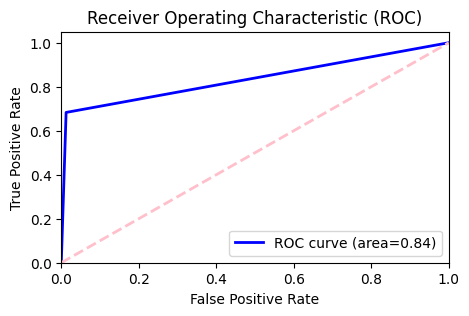

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, nb_y_pred)
roc_auc = roc_auc_score(y_test, nb_y_pred)
plt.figure(figsize = (5, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color = 'pink', lw = 2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.savefig("roc_naivebayes.jpeg", dpi=300, bbox_inches='tight')
plt.show()

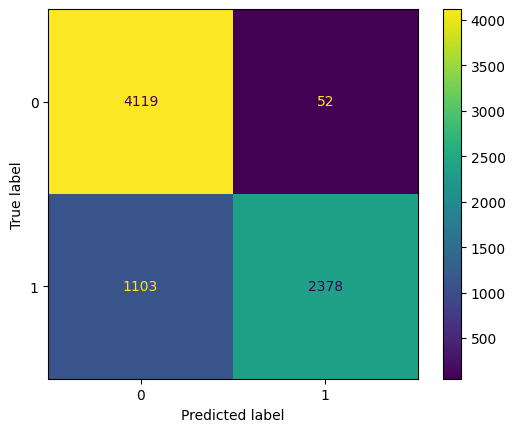

In [ ]:
# confusion matrix
matrix = confusion_matrix(y_test, nb_y_pred, labels=naivebayes.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=naivebayes.classes_)
disp.plot()
plt.savefig("cm_naivebayes", dpi=300, bbox_inches='tight')
plt.show()

### Support Vector Machine

In [ ]:
# Initialize the Support Vector Machine classifier
svm = SVC(kernel='linear')

# Fit the classifier to the training data
svm.fit(X_train, y_train)

# Predict the labels for the test data
svm_y_pred = svm.predict(X_test)

Model Evaluation

In [ ]:
# accuracy
SVM_accuracy = accuracy_score(svm_y_pred, y_test) * 100
print('Accuracy for SVM: %.3f' % SVM_accuracy)

# precision
SVM_precision = precision_score(svm_y_pred, y_test, average='binary') * 100
print('Precision for SVM: %.3f' % SVM_precision)

# recall
SVM_recall = recall_score(svm_y_pred, y_test, average='binary') * 100
print('Recall for SVM: %.3f' % SVM_recall)

# F1 score
SVM_F1_score = f1_score(svm_y_pred, y_test, average='binary') * 100
print('F1 score for SVM: %.3f' % SVM_F1_score)

Accuracy for SVM: 97.112
Precision for SVM: 96.036
Recall for SVM: 97.577
F1 score for SVM: 96.800


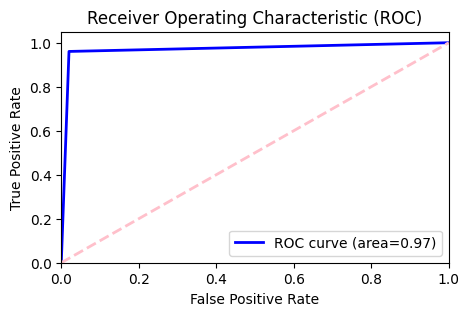

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, svm_y_pred)
roc_auc = roc_auc_score(y_test, svm_y_pred)
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='pink', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.savefig("roc_svm.jpeg", dpi=300, bbox_inches='tight')
plt.show()

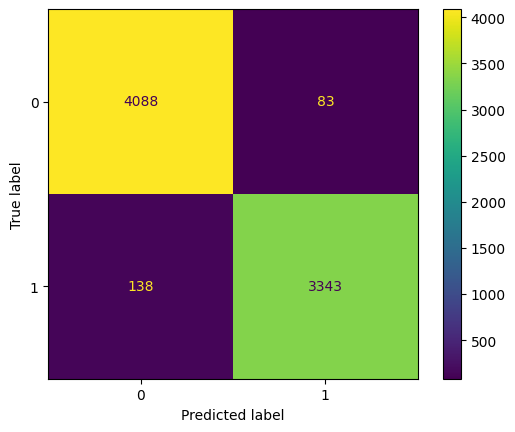

In [ ]:
# confusion matrix
matrix = confusion_matrix(y_test, svm_y_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=svm.classes_)
disp.plot()
plt.savefig("cm_svm", dpi=300, bbox_inches='tight')
plt.show()

### Random Forest

In [ ]:
# Initialize the Random Forest classifier
randomforest = RandomForestClassifier(n_estimators=100, random_state=2310246)

# Fit the classifier to the training data
randomforest.fit(X_train, y_train)

# Predict the labels for the test data
rf_y_pred = randomforest.predict(X_test)

Model Evaluation

In [ ]:
# accuracy
RF_accuracy = accuracy_score(rf_y_pred, y_test) * 100
print('Accuracy for Random Forest: %.3f' % RF_accuracy)

# precision
RF_precision = precision_score(rf_y_pred, y_test, average='binary') * 100
print('Precision for Random Forest: %.3f' % RF_precision)

# recall
RF_recall = recall_score(rf_y_pred, y_test, average='binary') * 100
print('Recall for Random Forest: %.3f' % RF_recall)

# F1 score
RF_F1_score = f1_score(rf_y_pred, y_test, average='binary') * 100
print('F1 score for Random Forest: %.3f' % RF_F1_score)

Accuracy for Random Forest: 95.740
Precision for Random Forest: 94.111
Recall for Random Forest: 96.438
F1 score for Random Forest: 95.260


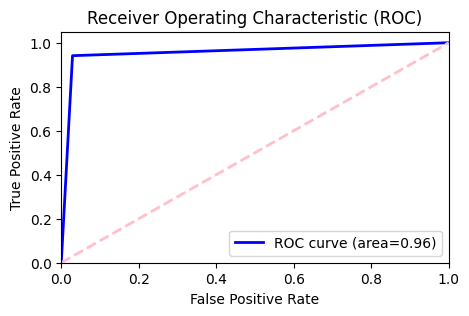

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_y_pred)
roc_auc = roc_auc_score(y_test, rf_y_pred)
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='pink', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.savefig("roc_rf.jpeg", dpi=300, bbox_inches='tight')
plt.show()

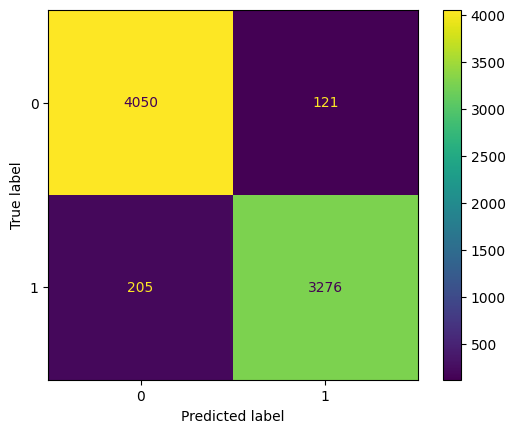

In [ ]:
# confusion matrix
matrix = confusion_matrix(y_test, rf_y_pred, labels=randomforest.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=randomforest.classes_)
disp.plot()
plt.savefig("cm_rf", dpi=300, bbox_inches='tight')
plt.show()

### XGBoost

In [ ]:
# Initialize the XGBoost classifier
xgboost = XGBClassifier(use_label_encoder=False)

# Fit the classifier to the training data
xgboost.fit(X_train, y_train)

# Predict the labels for the test data
xgb_y_pred = xgboost.predict(X_test)

Model Evaluation

In [ ]:
# accuracy
XGB_accuracy = accuracy_score(xgb_y_pred, y_test) * 100
print('Accuracy for XGBoost: %.3f' % XGB_accuracy)

# precision
XGB_precision = precision_score(xgb_y_pred, y_test, average='binary') * 100
print('Precision for XGBoost: %.3f' % XGB_precision)

# recall
XGB_recall = recall_score(xgb_y_pred, y_test, average='binary') * 100
print('Recall for XGBoost: %.3f' % XGB_recall)

# F1 score
XGB_F1_score = f1_score(xgb_y_pred, y_test, average='binary') * 100
print('F1 score for XGBoost: %.3f' % XGB_F1_score)

Accuracy for XGBoost: 97.791
Precision for XGBoost: 96.639
Recall for XGBoost: 98.478
F1 score for XGBoost: 97.550


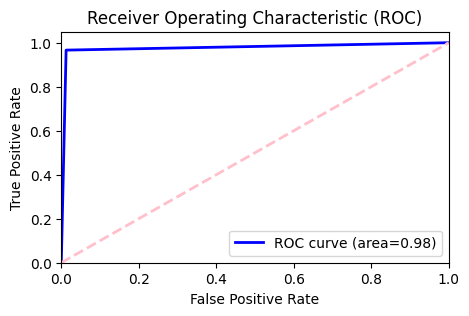

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, xgb_y_pred)
roc_auc = roc_auc_score(y_test, xgb_y_pred)
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='pink', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.savefig("roc_xgb.jpeg", dpi=300, bbox_inches='tight')
plt.show()

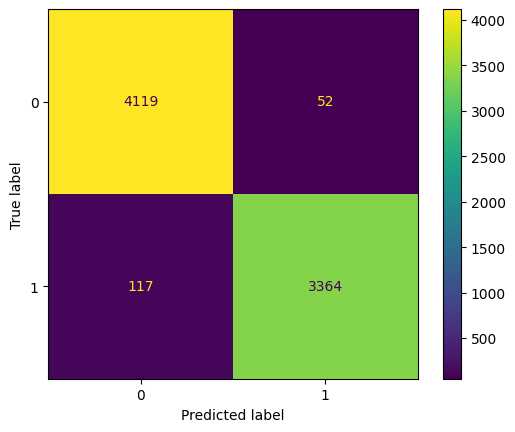

In [ ]:
# confusion matrix
matrix = confusion_matrix(y_test, xgb_y_pred, labels=xgboost.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=xgboost.classes_)
disp.plot()
plt.savefig("cm_xgb", dpi=300, bbox_inches='tight')
plt.show()

## Research Q3

### Sentimental features

In [ ]:
df_scale_senti.head()

,subjectivity,polarity,positive_word_percent,negative_word_percent
0,0.433422,0.542645,0.021739,0.027174
1,0.372436,0.579808,0.035398,0.000000
2,0.355556,0.479514,0.000000,0.064103
3,0.462055,0.532823,0.055944,0.027972
4,0.362774,0.508483,0.024221,0.020761


In [ ]:
# sentimental features
X_senti = df_scale_senti

# target variable
y = df_news_features['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_senti, y, test_size=0.2, random_state=2310246)

In [ ]:
# model training
xgboost_sf = XGBClassifier(use_label_encoder=False)
xgboost_sf.fit(X_train, y_train)
xgb_sf_y_pred = xgboost_sf.predict(X_test)

Evaluation Metrics

In [ ]:
# accuracy
XGB_sf_accuracy = accuracy_score(xgb_sf_y_pred, y_test) * 100
print('Accuracy for XGBoost: %.3f' % XGB_sf_accuracy)

# precision
XGB_sf_precision = precision_score(xgb_sf_y_pred, y_test, average='binary') * 100
print('Precision for XGBoost: %.3f' % XGB_sf_precision)

# recall
XGB_sf_recall = recall_score(xgb_sf_y_pred, y_test, average='binary') * 100
print('Recall for XGBoost: %.3f' % XGB_sf_recall)

# F1 score
XGB_sf_F1_score = f1_score(xgb_sf_y_pred, y_test, average='binary') * 100
print('F1 score for XGBoost: %.3f' % XGB_sf_F1_score)

Accuracy for XGBoost: 73.876
Precision for XGBoost: 64.780
Recall for XGBoost: 74.472
F1 score for XGBoost: 69.289


### Sentimental features and selected features

In [ ]:
# concatenate features
df_m2 = pd.concat([df_my_features, df_vec, df_scale_senti], axis = 1)
df_m2.head()

,Flesch_reading_score,char_count,word_count,syllable_count,lc_count,subject_left-news,PROPN,uc_count,punc_count,subject_politicsNews,NOUN,VERB,sent_count,INTJ,ADP,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,subjectivity,polarity,positive_word_percent,negative_word_percent
0,0.936225,0.042575,0.045252,0.037743,0.045306,0.0,0.026370,0.035144,0.006372,0.0,0.046586,0.047297,0.046875,0.000000,0.087719,0.399135,0.455526,0.657468,0.602104,0.425893,0.447562,0.394334,0.314261,0.565208,0.610248,0.612617,0.304197,0.522921,0.412478,0.376801,0.486714,0.325744,0.345882,0.433889,0.575654,0.493427,0.645459,0.507259,0.492170,0.540235,0.433117,0.375220,0.663405,0.517485,0.387445,0.379450,0.609071,0.534763,0.593917,0.568504,0.596267,0.362409,0.557522,0.526488,0.392916,0.616144,0.618041,0.458940,0.395075,0.564089,0.646407,0.583600,0.459396,0.433233,0.488726,0.631897,0.638907,0.465420,0.553696,0.333028,0.528750,0.303614,0.477524,0.686387,0.490556,0.406309,0.639506,0.505488,0.580228,0.512947,0.410368,0.337197,0.357910,0.733516,0.407595,0.681135,0.669139,0.550386,0.524818,0.549349,0.523799,0.553829,0.380859,0.414980,0.479718,0.511176,0.678886,0.475287,0.471261,0.390536,0.384849,0.536290,0.495248,0.514220,0.408890,0.522013,0.394142,0.605058,0.558094,0.480282,0.324324,0.577239,0.519582,0.368164,0.673030,0.433422,0.542645,0.021739,0.027174
1,0.918043,0.028594,0.027695,0.026687,0.026557,0.0,0.019778,0.017039,0.003740,1.0,0.022974,0.040541,0.028125,0.000000,0.000000,0.520438,0.468664,0.575267,0.525772,0.507641,0.598157,0.246713,0.256306,0.505514,0.601935,0.562047,0.143662,0.516158,0.274849,0.507409,0.637429,0.427455,0.393293,0.243804,0.325757,0.546831,0.547425,0.447258,0.623892,0.469060,0.502755,0.477772,0.677625,0.543817,0.457050,0.357523,0.621247,0.563241,0.623239,0.638009,0.581158,0.391558,0.573814,0.467581,0.551810,0.720747,0.701298,0.568195,0.488478,0.554177,0.705603,0.474045,0.538523,0.544652,0.532358,0.526111,0.568624,0.626136,0.682630,0.280747,0.473368,0.427963,0.517457,0.583285,0.491928,0.503299,0.465835,0.505128,0.605313,0.582804,0.601166,0.349357,0.229494,0.644429,0.485147,0.671851,0.637512,0.459479,0.501498,0.494374,0.499474,0.587979,0.488785,0.461557,0.460739,0.574476,0.721369,0.435467,0.476575,0.434129,0.519829,0.517466,0.536871,0.543243,0.368450,0.463382,0.242999,0.644134,0.376751,0.337757,0.266630,0.468424,0.500882,0.318583,0.817361,0.372436,0.579808,0.035398,0.000000
2,0.930658,0.018655,0.019041,0.019443,0.018376,0.0,0.015245,0.014909,0.002355,1.0,0.016592,0.013514,0.009375,0.058824,0.035088,0.575975,0.347513,0.650245,0.478905,0.401009,0.632654,0.336994,0.138734,0.478955,0.615655,0.583907,0.254896,0.432695,0.371427,0.560353,0.693716,0.374604,0.421322,0.351340,0.392979,0.527031,0.540895,0.662731,0.450440,0.419786,0.524092,0.383778,0.737638,0.555130,0.354856,0.375284,0.685166,0.584477,0.575273,0.538785,0.564025,0.553401,0.512418,0.437889,0.564568,0.722084,0.718232,0.606798,0.510399,0.518675,0.529568,0.493706,0.527461,0.572833,0.479531,0.587087,0.722811,0.560189,0.526286,0.287756,0.495598,0.354009,0.534604,0.633299,0.484526,0.360275,0.420768,0.578341,0.680913,0.636810,0.484792,0.432273,0.331141,0.629102,0.389831,0.704205,0.779953,0.417183,0.520716,0.557713,0.492913,0.692267,0.379486,0.355441,0.431368,0.596997,0.619924,0.528281,0.519218,0.350116,0.359742,0.630684,0.655188,0.363326,0.408630,0.512711,0.377142,0.565182,0.527573,0.515782,0.357536,0.545905,0.360079,0.350460,0.797036,0.355556,0.479514,0.000000,0.064103
3,0.945971,0.066125,0.070475,0.068242,0.073107,0.0,0.039143,0.041534,0.011774,1.0,0.079132,0.067568,0.090625,0.000000,0.035088,0.626873,0.423004,0.560184,0.484801,0.372795,0.481443,0.382007,0.327866,0.533280,0.553905,0.582636,0.407954,0.463223,0.411443,0.477713,0.545169,0.368792,0.418987,0.5

In [ ]:
X = df_m2
y = df_news_features['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2310246)

In [ ]:
# model training
senti_xgb2 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
senti_xgb2.fit(X_train, y_train)
xgb2_y_pred = senti_xgb2.predict(X_test)

Model Evaluation

In [ ]:
# accuracy
XGB2_accuracy = accuracy_score(xgb2_y_pred, y_test) * 100
print('Accuracy for XGBoost: %.3f' % XGB2_accuracy)

# precision
XGB2_precision = precision_score(xgb2_y_pred, y_test, average='binary') * 100
print('Precision for XGBoost: %.3f' % XGB2_precision)

# recall
XGB2_recall = recall_score(xgb2_y_pred, y_test, average='binary') * 100
print('Recall for XGBoost: %.3f' % XGB2_recall)

# F1 score
XGB2_F1_score = f1_score(xgb2_y_pred, y_test, average='binary') * 100
print('F1 score for XGBoost: %.3f' % XGB2_F1_score)

Accuracy for XGBoost: 97.778
Precision for XGBoost: 96.754
Recall for XGBoost: 98.336
F1 score for XGBoost: 97.538


Feature importance

In [ ]:
# Get the feature importances from the trained XGBoost model
imp = senti_xgb2.feature_importances_

# Get the feature names from the dataframe columns
feature_names = df_m2.columns

# Create a DataFrame to store the feature names and their importances
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': imp})

# Sort the DataFrame by the importance values in descending order
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
feature_imp_df

,Feature,Importance
55,40,0.342963
105,90,0.079727
67,52,0.057580
5,subject_left-news,0.035129
9,subject_politicsNews,0.033320
81,66,0.033032
17,2,0.024091
113,98,0.020590
1,char_count,0.019770
98,83,0.015537
